In [5]:
import pandas as pd
from data_builder import DataBuilder
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def standardizer(input_array):
    mean = np.mean(input_array)
    std = np.std(input_array)
    standardized_array = (input_array - mean) / std
    return standardized_array

In [7]:
beam_break_data = pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/master_binary.csv')
beam_break_data

/tmp/ipykernel_3522810/1559551854.py:1: DtypeWarning: Columns (1,2,20079) have mixed types. Specify dtype option on import or set low_memory=False.
  beam_break_data = pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/master_binary.csv')


,FlyID,Genotype_SpecSheet,Genotype (F>M),RunName,Monitor,Channel,StartMeta,EndMeta,TimeLen,t0,...,t20062,t20063,t20064,t20065,t20066,t20067,Average bout length/D,Activity/waking min,Genotype (FxM)_specsheet,Genotype (FxM)
0,M106_M118_Ch25,Londonxalrm_1_M,London>alrm,M106,118,25,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,88.206897,2.891771,NaN,NaN
1,M106_M118_Ch26,Londonxalrm_1_M,London>alrm,M106,118,26,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90.576923,1.933168,NaN,NaN
2,M106_M118_Ch27,Londonxalrm_1_M,London>alrm,M106,118,27,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,62.487179,2.523714,NaN,NaN
3,M106_M118_Ch28,Londonxalrm_1_M,London>alrm,M106,118,28,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,216.083333,1.665618,NaN,NaN
4,M106_M118_Ch29,Londonxalrm_1_M,London>alrm,M106,118,29,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,39.933333,2.639334,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1358,M96_M48_Ch28,elav>attp2vF,NaN,M96,48,28,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,2.0,1.0,3.0,2.0,1.0,1.0,86.413793,2.272366,NaN,NaN
1359,M96_M48_Ch29,elav>attp2vF,NaN,M96,48,29,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,2.0,2.0,1.0,1.0,2.0,2.0,28.743243,2.505122,NaN,NaN
1360,M96_M48_Ch30,elav>attp2vF,NaN,M96,48,30,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,26.519481,2.455212,NaN,NaN
1361,M96_M48_Ch31,elav>attp2vF,NaN,M96,48,31,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,3.0,0.0,1.0,1.0,0.0,1.0,48.088889,2.453503,NaN,NaN


In [8]:
beam_break_data['Genotype_SpecSheet'].isna().sum()

157

In [9]:
beam_break_data = beam_break_data.dropna(subset='Genotype_SpecSheet').reset_index(drop=True)
beam_break_data

,FlyID,Genotype_SpecSheet,Genotype (F>M),RunName,Monitor,Channel,StartMeta,EndMeta,TimeLen,t0,...,t20062,t20063,t20064,t20065,t20066,t20067,Average bout length/D,Activity/waking min,Genotype (FxM)_specsheet,Genotype (FxM)
0,M106_M118_Ch25,Londonxalrm_1_M,London>alrm,M106,118,25,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,88.206897,2.891771,NaN,NaN
1,M106_M118_Ch26,Londonxalrm_1_M,London>alrm,M106,118,26,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90.576923,1.933168,NaN,NaN
2,M106_M118_Ch27,Londonxalrm_1_M,London>alrm,M106,118,27,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,62.487179,2.523714,NaN,NaN
3,M106_M118_Ch28,Londonxalrm_1_M,London>alrm,M106,118,28,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,216.083333,1.665618,NaN,NaN
4,M106_M118_Ch29,Londonxalrm_1_M,London>alrm,M106,118,29,139834 | 12 Dec 24 | 13:25:00 | 51 | 0 | 118 |...,161518 | 27 Dec 24 | 14:49:00 | 51 | 0 | 118 |...,21685,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,39.933333,2.639334,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,NaN,M96,48,28,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,2.0,1.0,3.0,2.0,1.0,1.0,86.413793,2.272366,NaN,NaN
1202,M96_M48_Ch29,elav>attp2vF,NaN,M96,48,29,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,2.0,2.0,1.0,1.0,2.0,2.0,28.743243,2.505122,NaN,NaN
1203,M96_M48_Ch30,elav>attp2vF,NaN,M96,48,30,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,26.519481,2.455212,NaN,NaN
1204,M96_M48_Ch31,elav>attp2vF,NaN,M96,48,31,161390 | 21 Nov 24 | 12:10:00 | 51 | 0 | 48 | ...,181531 | 5 Dec 24 | 11:51:00 | 51 | 0 | 48 | 0...,20142,0.0,...,3.0,0.0,1.0,1.0,0.0,1.0,48.088889,2.453503,NaN,NaN


In [10]:
beam_break_data.columns

Index(['FlyID', 'Genotype_SpecSheet', 'Genotype (F>M)', 'RunName', 'Monitor',
       'Channel', 'StartMeta', 'EndMeta', 'TimeLen', 't0',
       ...
       't20062', 't20063', 't20064', 't20065', 't20066', 't20067',
       'Average bout length/D', 'Activity/waking min',
       'Genotype (FxM)_specsheet', 'Genotype (FxM)'],
      dtype='object', length=20081)

In [11]:
beam_break_data['Genotype_SpecSheet'].unique()

array(['Londonxalrm_1_M', 'Londonxalrm_2_F', 'Londonxalrm_2_M',
       'Londonxalrm_3_F', 'Londonxalrm_3_M', 'Londonxattp2_1_F',
       'Londonxattp2_1_M', 'Londonxattp2_2_F', 'Londonxattp2_2_M',
       'Londonxattp2_3_F', 'Londonxattp2_3_M', 'Londonxattp40_2_F',
       'Londonxattp40_2_M', 'Londonxattp40_3_F', 'Londonxattp40_3_M',
       'Londonxrepo_1_F', 'Londonxrepo_2_F', 'Londonxrepo_2_M',
       'Londonxrepo_3_F', 'Londonxrepo_3_M', 'SwedArcxattp2_1_F',
       'SwedArcxattp2_1_M', 'SwedArcxattp2_3_F', 'SwedArcxattp2_3_M',
       'SwedArcxrepo_1_F', 'SwedArcxrepo_1_M', 'SwedArcxrepo_3_F',
       'SwedArcxrepo_3_M', 'Swedishxattp2_1_F', 'Swedishxattp2_1_M',
       'Swedishxattp2_2_F', 'Swedishxattp2_2_M', 'Swedishxrepo_1_F',
       'Swedishxrepo_1_M', 'Swedishxrepo_2_F', 'Swedishxrepo_2_M',
       'attp2xQA40_1_F', 'attp2xQA40_1_M', 'attp2xQA40_3_F',
       'attp2xQA40_3_M', 'attp2xQA42_1_F', 'attp2xQA42_1_M',
       'attp2xQA42_3_F', 'attp2xQA42_3_M', 'attp2xalrm_1_M',
       'att

In [12]:
beam_break_data.columns[9:-4]

Index(['t0', 't1', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9',
       ...
       't20058', 't20059', 't20060', 't20061', 't20062', 't20063', 't20064',
       't20065', 't20066', 't20067'],
      dtype='object', length=20068)

In [13]:
beam_break_data.iloc[:, 9:-4]

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t20058,t20059,t20060,t20061,t20062,t20063,t20064,t20065,t20066,t20067
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,2.0,2.0,2.0,2.0,1.0,3.0,2.0,1.0,1.0
1202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,3.0,3.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0
1203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
1204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,2.0,3.0,0.0,1.0,1.0,0.0,1.0


In [14]:
# beam_break_data_standardized = beam_break_data[['FlyID', 'Genotype_SpecSheet']]

In [15]:
# full_standardized = standardizer(beam_break_data.iloc[:, 9:-4].values)

In [16]:
# new_time_columns = [f't{i}' for i in range(int(20068))]
# full_beam_binned_standardized_df = pd.DataFrame(
#     data = full_standardized, 
#     columns=new_time_columns
# )
# full_beam_binned_standardized_df

In [17]:
# full_beam_break_data_standardized = pd.concat([beam_break_data_standardized, full_beam_binned_standardized_df], axis=1)
# full_beam_break_data_standardized

In [18]:
# full_beam_break_data_standardized.iloc[:, 2:]

In [19]:
# full_beam_break_data_standardized.to_csv('/home/rachel/Desktop/mm-vae_ext2/data/full_beam_break_standardized.csv', index=False)

In [20]:
beam_break_data_binned = beam_break_data[['FlyID', 'Genotype_SpecSheet']]
beam_break_data_binned

,FlyID,Genotype_SpecSheet
0,M106_M118_Ch25,Londonxalrm_1_M
1,M106_M118_Ch26,Londonxalrm_1_M
2,M106_M118_Ch27,Londonxalrm_1_M
3,M106_M118_Ch28,Londonxalrm_1_M
4,M106_M118_Ch29,Londonxalrm_1_M
...,...,...
1201,M96_M48_Ch28,elav>attp2vF
1202,M96_M48_Ch29,elav>attp2vF
1203,M96_M48_Ch30,elav>attp2vF
1204,M96_M48_Ch31,elav>attp2vF


In [21]:
beam_break_data_binned_length = beam_break_data.iloc[:, 9:-4].shape[1] / 4
beam_break_data_binned_length

5017.0

In [22]:
beam_break_data.iloc[:, 9:-4].values

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [23]:
beam_data = beam_break_data.iloc[:, 9:-4].values
beam_bins = beam_data.reshape(beam_break_data.shape[0], int(beam_break_data_binned_length), 4)
beam_bins.shape

(1206, 5017, 4)

In [24]:
beam_binned = beam_bins.sum(axis=2)
beam_binned.shape

(1206, 5017)

In [25]:
new_time_columns = [f't{i}' for i in range(int(beam_break_data_binned_length))]
beam_binned_df = pd.DataFrame(
    data = beam_binned, 
    columns=new_time_columns
)
beam_binned_df

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,16.0,7.0,28.0,1.0,3.0,6.0,27.0,4.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,8.0,7.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,6.0,9.0,8.0,8.0,7.0,6.0,7.0,7.0
1202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,9.0,8.0,6.0,8.0,10.0,8.0,10.0,9.0,6.0
1203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,4.0,2.0,0.0,0.0,0.0,3.0,3.0,3.0
1204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,3.0,3.0,9.0,3.0,4.0,10.0,1.0,5.0,3.0


In [26]:
final_beam_break_binned = pd.concat([beam_break_data_binned, beam_binned_df], axis=1)
final_beam_break_binned

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,16.0,7.0,28.0,1.0,3.0,6.0,27.0,4.0,0.0
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,8.0,7.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,6.0,9.0,8.0,8.0,7.0,6.0,7.0,7.0
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,9.0,8.0,6.0,8.0,10.0,8.0,10.0,9.0,6.0
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,4.0,2.0,0.0,0.0,0.0,3.0,3.0,3.0
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,3.0,3.0,9.0,3.0,4.0,10.0,1.0,5.0,3.0


In [27]:
final_beam_break_binned.to_csv('/home/rachel/Desktop/mm-vae_ext2/data/raw_beam_break_binned.csv', index=False)

In [28]:
raw_beam_break_binned = pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/raw_beam_break_binned.csv')
raw_beam_break_binned

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,16.0,7.0,28.0,1.0,3.0,6.0,27.0,4.0,0.0
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,8.0,7.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,6.0,9.0,8.0,8.0,7.0,6.0,7.0,7.0
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,9.0,8.0,6.0,8.0,10.0,8.0,10.0,9.0,6.0
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,4.0,4.0,2.0,0.0,0.0,0.0,3.0,3.0,3.0
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,3.0,3.0,9.0,3.0,4.0,10.0,1.0,5.0,3.0


In [29]:
len(raw_beam_break_binned['FlyID'].unique())

1206

In [30]:
raw_beam_break_binned['mean'] = raw_beam_break_binned[new_time_columns].mean(axis=1)
raw_beam_break_binned['std'] = raw_beam_break_binned[new_time_columns].std(axis=1)
raw_beam_break_binned

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016,mean,std
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.952960,5.742877
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.100857,4.434419
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.563086,5.732999
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.0,28.0,1.0,3.0,6.0,27.0,4.0,0.0,2.394260,4.216059
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,8.0,7.0,4.0,0.0,2.630257,6.064169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,9.0,8.0,8.0,7.0,6.0,7.0,7.0,3.234403,4.484697
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,8.0,6.0,8.0,10.0,8.0,10.0,9.0,6.0,4.590991,5.169201
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,2.0,0.0,0.0,0.0,3.0,3.0,3.0,3.341838,4.449046
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,9.0,3.0,4.0,10.0,1.0,5.0,3.0,3.252342,4.395348


In [31]:
raw_beam_break_binned['Percent_zero'] = (raw_beam_break_binned[new_time_columns] == 0.0).sum(axis=1) / 5017
raw_beam_break_binned

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5010,t5011,t5012,t5013,t5014,t5015,t5016,mean,std,Percent_zero
0,M106_M118_Ch25,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.952960,5.742877,0.755232
1,M106_M118_Ch26,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.100857,4.434419,0.656767
2,M106_M118_Ch27,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.563086,5.732999,0.688459
3,M106_M118_Ch28,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,28.0,1.0,3.0,6.0,27.0,4.0,0.0,2.394260,4.216059,0.586805
4,M106_M118_Ch29,Londonxalrm_1_M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,8.0,7.0,4.0,0.0,2.630257,6.064169,0.672115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,8.0,8.0,7.0,6.0,7.0,7.0,3.234403,4.484697,0.494718
1202,M96_M48_Ch29,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,10.0,8.0,10.0,9.0,6.0,4.590991,5.169201,0.434722
1203,M96_M48_Ch30,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,3.0,3.0,3.0,3.341838,4.449046,0.430536
1204,M96_M48_Ch31,elav>attp2vF,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,3.0,4.0,10.0,1.0,5.0,3.0,3.252342,4.395348,0.495715


Text(0.5, 1.0, 'Mean beam breaks across samples')

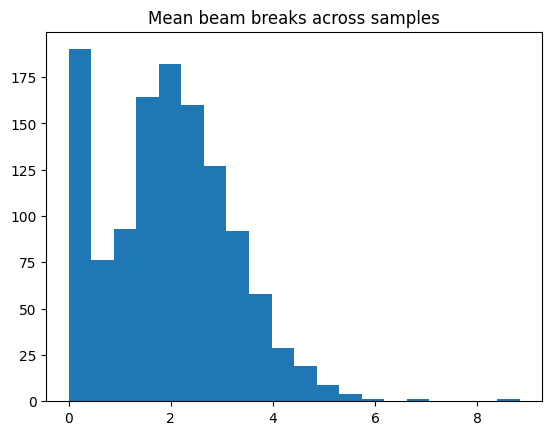

In [32]:
plt.hist(raw_beam_break_binned['mean'], bins=20)
plt.title('Mean beam breaks across samples')

Text(0.5, 1.0, 'Std beam breaks across samples')

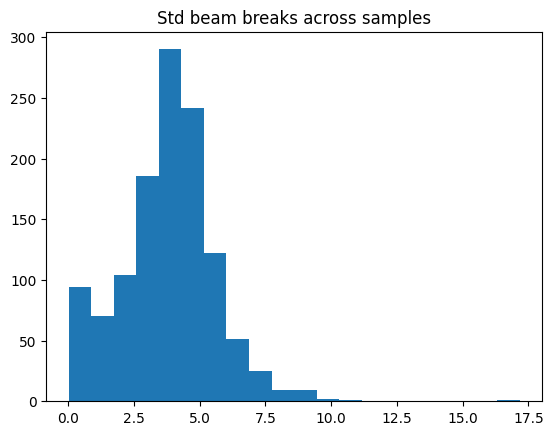

In [33]:
plt.hist(raw_beam_break_binned['std'], bins=20)
plt.title('Std beam breaks across samples')

Text(0.5, 1.0, 'Percent zero across samples')

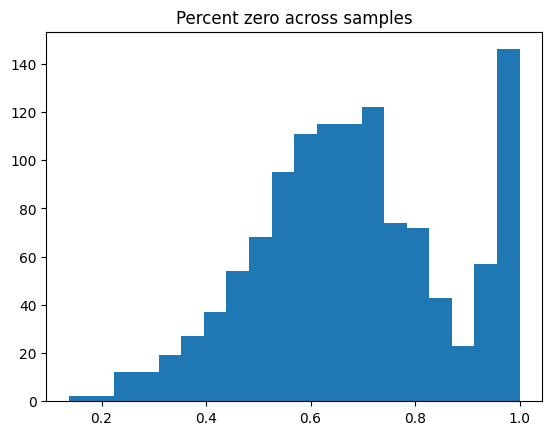

In [34]:
plt.hist(raw_beam_break_binned['Percent_zero'], bins=20)
plt.title('Percent zero across samples')

In [35]:
raw_beam_break_binned.iloc[:, 2:]

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t5010,t5011,t5012,t5013,t5014,t5015,t5016,mean,std,Percent_zero
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.952960,5.742877,0.755232
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.100857,4.434419,0.656767
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.563086,5.732999,0.688459
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,28.0,1.0,3.0,6.0,27.0,4.0,0.0,2.394260,4.216059,0.586805
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,8.0,7.0,4.0,0.0,2.630257,6.064169,0.672115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,8.0,8.0,7.0,6.0,7.0,7.0,3.234403,4.484697,0.494718
1202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,8.0,10.0,8.0,10.0,9.0,6.0,4.590991,5.169201,0.434722
1203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,3.0,3.0,3.0,3.341838,4.449046,0.430536
1204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,9.0,3.0,4.0,10.0,1.0,5.0,3.0,3.252342,4.395348,0.495715


In [36]:
beam_binned.shape

(1206, 5017)

In [37]:
np.mean(beam_binned), np.std(beam_binned)

(1.9607247464755817, 4.370635681815)

In [38]:
beam_binned_standardized = standardizer(beam_binned)
beam_binned_standardized

array([[-0.44861317, -0.44861317, -0.44861317, ..., -0.44861317,
        -0.44861317, -0.44861317],
       [-0.44861317, -0.44861317, -0.44861317, ..., -0.44861317,
        -0.44861317, -0.44861317],
       [-0.44861317, -0.44861317, -0.44861317, ..., -0.44861317,
        -0.44861317, -0.44861317],
       ...,
       [-0.44861317, -0.44861317, -0.44861317, ...,  0.23778583,
         0.23778583,  0.23778583],
       [-0.44861317, -0.44861317, -0.44861317, ..., -0.2198135 ,
         0.69538517,  0.23778583],
       [-0.44861317, -0.44861317, -0.44861317, ...,  0.00898617,
        -0.2198135 , -0.44861317]])

In [39]:
new_time_columns = [f't{i}' for i in range(int(beam_break_data_binned_length))]
beam_binned_standardized_df = pd.DataFrame(
    data = beam_binned_standardized, 
    columns=new_time_columns
)
beam_binned_standardized_df

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
1,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
2,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
3,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.695385,3.212182,1.152985,5.957778,-0.219814,0.237786,0.924185,5.728978,0.466586,-0.448613
4,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,0.237786,1.381784,1.152985,0.466586,-0.448613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.924185,1.381784,0.924185,1.610584,1.381784,1.381784,1.152985,0.924185,1.152985,1.152985
1202,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,1.839384,1.610584,1.381784,0.924185,1.381784,1.839384,1.381784,1.839384,1.610584,0.924185
1203,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.466586,0.466586,0.466586,0.008986,-0.448613,-0.448613,-0.448613,0.237786,0.237786,0.237786
1204,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.924185,0.237786,0.237786,1.610584,0.237786,0.466586,1.839384,-0.219814,0.695385,0.237786


In [40]:
final_beam_break_standardized_binned = pd.concat([beam_break_data_binned, beam_binned_standardized_df], axis=1)
final_beam_break_standardized_binned

,FlyID,Genotype_SpecSheet,t0,t1,t2,t3,t4,t5,t6,t7,...,t5007,t5008,t5009,t5010,t5011,t5012,t5013,t5014,t5015,t5016
0,M106_M118_Ch25,Londonxalrm_1_M,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
1,M106_M118_Ch26,Londonxalrm_1_M,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
2,M106_M118_Ch27,Londonxalrm_1_M,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613
3,M106_M118_Ch28,Londonxalrm_1_M,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.695385,3.212182,1.152985,5.957778,-0.219814,0.237786,0.924185,5.728978,0.466586,-0.448613
4,M106_M118_Ch29,Londonxalrm_1_M,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,0.237786,1.381784,1.152985,0.466586,-0.448613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1201,M96_M48_Ch28,elav>attp2vF,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.924185,1.381784,0.924185,1.610584,1.381784,1.381784,1.152985,0.924185,1.152985,1.152985
1202,M96_M48_Ch29,elav>attp2vF,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,1.839384,1.610584,1.381784,0.924185,1.381784,1.839384,1.381784,1.839384,1.610584,0.924185
1203,M96_M48_Ch30,elav>attp2vF,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.466586,0.466586,0.466586,0.008986,-0.448613,-0.448613,-0.448613,0.237786,0.237786,0.237786
1204,M96_M48_Ch31,elav>attp2vF,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,-0.448613,...,0.924185,0.237786,0.237786,1.610584,0.237786,0.466586,1.839384,-0.219814,0.695385,0.237786


In [41]:
final_beam_break_standardized_binned.to_csv('/home/rachel/Desktop/mm-vae_ext2/data/raw_beam_break_standardized_binned_dropna.csv', index=False)

In [42]:
batch_size = 128
train_set = DataBuilder(raw_beam_break_binned)
test_set = DataBuilder(raw_beam_break_binned)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=len(test_set), shuffle=True)

In [43]:
data, fly_id, genotype = next(iter(train_loader))
print(data.shape)
print(len(fly_id))
print(len(genotype))

ValueError: too many values to unpack (expected 3)

In [ ]:
data

NameError: name 'data' is not defined

In [ ]:
fly_id

('M96_M80_Ch9',
 'M106_M7_Ch10',
 'M106_M4_Ch17',
 'M96_M24_Ch24',
 'M106_M14_Ch29',
 'M96_M49_Ch27',
 'M106_M119_Ch5',
 'M106_M29_Ch17',
 'M96_M57_Ch5',
 'M106_M33_Ch1',
 'M106_M116_Ch32',
 'M96_M76_Ch5',
 'M96_M10_Ch29',
 'M106_M111_Ch10',
 'M106_M24_Ch31',
 'M96_M9_Ch13',
 'M106_M15_Ch15',
 'M96_M54_Ch7',
 'M106_M16_Ch25',
 'M119_M50_Ch7',
 'M153_M28_Ch2',
 'M106_M111_Ch31',
 'M96_M56_Ch6',
 'M96_M76_Ch4',
 'M96_M8_Ch26',
 'M106_M4_Ch23',
 'M153_M27_Ch28',
 'M153_M28_Ch1',
 'M106_M30_Ch13',
 'M106_M22_Ch17',
 'M96_M48_Ch6',
 'M96_M76_Ch14',
 'M153_M30_Ch17',
 'M96_M10_Ch2',
 'M96_M55_Ch9',
 'M106_M118_Ch5',
 'M96_M29_Ch1',
 'M106_M117_Ch22',
 'M106_M22_Ch16',
 'M106_M15_Ch29',
 'M96_M10_Ch18',
 'M106_M111_Ch13',
 'M106_M7_Ch13',
 'M106_M116_Ch8',
 'M96_M9_Ch1',
 'M96_M50_Ch15',
 'M96_M24_Ch6',
 'M96_M56_Ch24',
 'M119_M50_Ch21',
 'M106_M30_Ch10',
 'M106_M117_Ch9',
 'M153_M30_Ch22',
 'M96_M25_Ch18',
 'M106_M30_Ch2',
 'M96_M48_Ch18',
 'M96_M55_Ch15',
 'M96_M24_Ch31',
 'M106_M15_Ch10',


In [ ]:
genotype

('SwedArc>attp2M',
 'elavQFxattp40_3_F',
 'elavQFxattp2_1_M',
 'Swed>nsybG4F',
 'Swedishxattp2_1_F',
 'SwedArc>alrmF',
 'attp2xrepo_3_M',
 'attp2xQA40_3_M',
 'London>elavF',
 'attp2xQA42_1_M',
 'Londonxrepo_3_F',
 'London>attp2M',
 'SwedArc>nsybG4F',
 'attp40xQA42_3_F',
 'Swedishxrepo_1_F',
 'London>nsybG4vF',
 'SwedArcxrepo_3_F',
 'London>alrmvF',
 'attp40xalrm_3_F',
 'elavQFxQAb40_F',
 nan,
 'attp40xQA42_1_F',
 'alrm>attp2M',
 'London>attp2M',
 'London>nsybG4F',
 'elavQFxattp2_1_M',
 nan,
 nan,
 'attp2xQA40_1_F',
 'attp40xrepo_3_F',
 'elav>SwedArcM',
 'London>attp2M',
 nan,
 'SwedArc>nsybG4m',
 'elav>attp2M',
 'Londonxalrm_3_F',
 'attp2>nsybG4M',
 'Londonxrepo_1_F',
 'attp40xrepo_3_F',
 'SwedArcxrepo_1_F',
 'SwedArc>nsybG4F',
 'attp40xQA42_3_F',
 'elavQFxattp40_3_F',
 'Londonxattp40_2_M',
 'London>nsybG4vF',
 'London>alrmM',
 'Swed>nsybG4M',
 'alrm>attp2F',
 'attp40xQAb40_F',
 'attp2xQA40_1_F',
 'Londonxrepo_2_F',
 nan,
 'attp2>nsybG4vF',
 'attp2xQA40_1_M',
 'elav>attp2vF',
 'elav>at

In [ ]:
data_test, fly_id_test, genotype_test = next(iter(test_loader))
print(data_test.shape)
print(len(fly_id_test))
print(len(genotype_test))

torch.Size([1363, 5017])
1363
1363


Eigen decomposition of the raw beam break data

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
beam_binned

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 3., 3., 3.],
       [0., 0., 0., ..., 1., 5., 3.],
       [0., 0., 0., ..., 2., 1., 0.]])

In [ ]:
beam_binned.shape

(1206, 5017)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(beam_binned)

NameError: name 'StandardScaler' is not defined

In [ ]:
X_scaled

array([[ 0.        ,  0.        ,  0.        , ..., -0.50662774,
        -0.45069246, -0.45693721],
       [ 0.        ,  0.        ,  0.        , ..., -0.50662774,
        -0.45069246, -0.45693721],
       [ 0.        ,  0.        ,  0.        , ..., -0.50662774,
        -0.45069246, -0.45693721],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.53365555,
         0.44327976,  0.44694405],
       [ 0.        ,  0.        ,  0.        , ..., -0.15986664,
         1.03926124,  0.44694405],
       [ 0.        ,  0.        ,  0.        , ...,  0.18689446,
        -0.15270172, -0.45693721]])

In [ ]:
pca = PCA()
pca.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [ ]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

In [ ]:
cumulative_variance.shape

(1206,)

In [ ]:
cumulative_variance

array([0.10019965, 0.12968439, 0.14705978, ..., 1.        , 1.        ,
       1.        ])

In [ ]:
index = np.where(cumulative_variance >= 0.90)[0][0]
k = index+1
k

617

Text(0.5, 1.0, 'Cumulative variance across components')

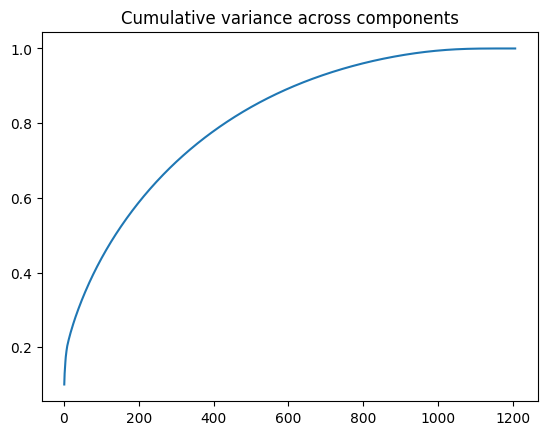

In [ ]:
num_components = range(1, 1207)
plt.plot(num_components, cumulative_variance)
plt.title('Cumulative variance across components')

Text(0.5, 1.0, 'Eigenvalues')

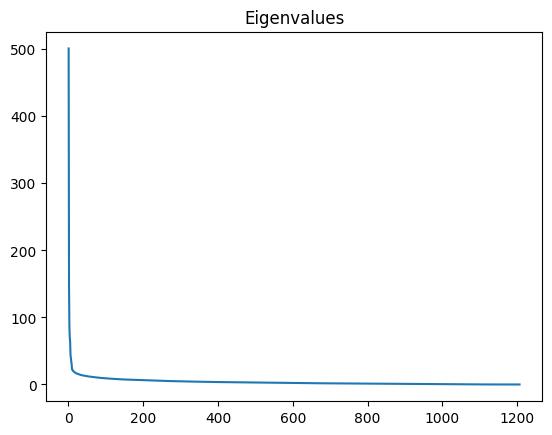

In [ ]:
plt.plot(num_components, pca.explained_variance_)
plt.title('Eigenvalues')

In [ ]:
from kneed import KneeLocator

In [ ]:
elbow = KneeLocator(num_components, pca.explained_variance_, S=1.0, curve='convex', direction='decreasing')

In [ ]:
elbow.knee, elbow.knee_y

(19, 17.273357598681205)

Text(0.5, 1.0, 'Eigenvalues')

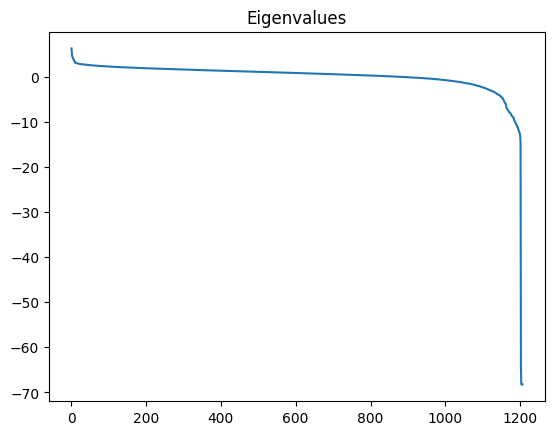

In [ ]:
plt.plot(num_components, np.log(pca.explained_variance_))
plt.title('Eigenvalues')

In [ ]:
ind = np.where(pca.explained_variance_ < 10)
ind[0][0]

84

In [ ]:
pca.explained_variance_[20]

16.67549444898621

In [ ]:
np.log(pca.explained_variance_[20])

2.813940243475188

In [ ]:
pca.explained_variance_ratio_[19]

0.003392363797651214

Text(0.5, 1.0, 'Explained variance ratio')

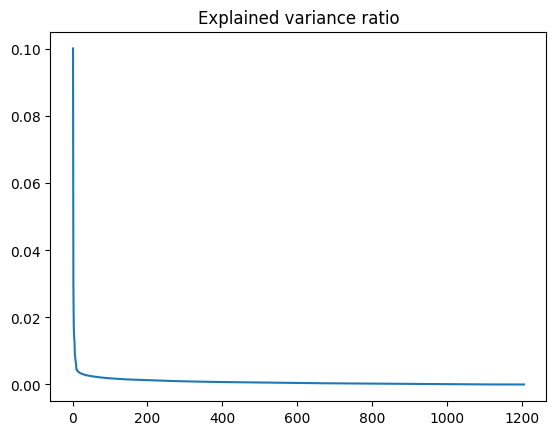

In [ ]:
plt.plot(num_components, pca.explained_variance_ratio_)
plt.title('Explained variance ratio')

In [ ]:
pca.explained_variance_ratio_

array([1.00199651e-01, 2.94847347e-02, 1.73753976e-02, ...,
       4.63251769e-34, 4.63251769e-34, 4.63251769e-34])

Examine aggregated data

In [49]:
agg_data = pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/cleaned_binary_summary_sheet.csv')
agg_data

,Genotype (F>M),Genotype (FxM),Driver,UAS,Sex,Run number,Monitor number,Channel,Triage for sleep(Last day of activity < 5),Sleep/Day (min),...,Average bout length/L,Average bout length/D,Total activity/L,Total activity/D,Activity/waking min/L,Activity/waking min /D,Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase
0,London>alrm,London>alrmF,alrm,London,F,M96,50,17,0,1042.00,...,43.763158,417.333333,522.25,299.00,0.509885,0.367322,0.375000,0.229259,23.0,9.0
1,London>alrm,London>alrmF,alrm,London,F,M96,50,18,0,744.25,...,19.226415,24.437500,679.00,549.25,0.572875,0.577398,-0.152887,0.115305,22.5,11.0
2,London>alrm,London>alrmF,alrm,London,F,M96,50,20,0,957.00,...,33.238095,143.294118,589.00,306.00,0.539872,0.368231,0.121118,0.092778,22.5,11.0
3,London>alrm,London>alrmF,alrm,London,F,M96,50,21,0,1030.75,...,28.620690,189.692308,366.75,263.75,0.357805,0.320279,0.018836,0.060599,22.0,11.0
4,London>alrm,London>alrmF,alrm,London,F,M96,50,22,0,855.25,...,19.867470,49.000000,481.50,597.50,0.468499,0.598098,0.094266,0.040316,22.0,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,7,0,1083.75,...,9.310559,355.750000,393.25,11.50,0.369162,0.015786,0.250000,0.059462,21.0,10.0
1336,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,8,0,1081.75,...,15.756098,25.210526,263.25,518.75,0.275510,0.616642,-0.175197,0.212707,19.5,10.0
1337,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,9,0,1097.75,...,15.218487,57.400000,330.25,407.50,0.334515,0.513063,0.027311,-0.069477,23.0,10.0
1338,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,11,0,777.00,...,8.718182,35.229508,411.75,190.25,0.343054,0.210745,-0.123177,0.142292,21.5,9.0


In [ ]:
len(agg_data['Genotype (F>M)'].unique())

52

In [ ]:
agg_data['Driver'].unique()

array(['alrm', 'attp2', 'elav', 'nsyb', 'attp40', 'repo', 'elavQF'],
      dtype=object)

In [ ]:
agg_data['UAS'].unique()

array(['London', 'Swedish', 'Swedish_Arctic', 'attp2', 'SwedArc', 'QA40',
       'QA42', 'attp40', 'QAb40', 'QAb42', 'Ab42-Arc', 'Ab42', '55672',
       '60104', '61340', '61939', '64626'], dtype=object)

In [ ]:
agg_data['Sex'].value_counts()

Sex
M     639
F     586
vF    115
Name: count, dtype: int64

In [ ]:
agg_data.iloc[:, 8:]

,Triage for sleep(Last day of activity < 5),Sleep/Day (min),Bout number/Day,Average bout length/Day,Total activity/Day,Activity/waking min,Latency (min),Sleep/L (min),Sleep/D (min),Bout number/L,...,Average bout length/L,Average bout length/D,Total activity/L,Total activity/D,Activity/waking min/L,Activity/waking min /D,Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase
0,0,1042.00,10.75,96.930233,821.25,2.063442,72.00,415.75,626.00,9.50,...,43.763158,417.333333,522.25,299.00,0.509885,0.367322,0.375000,0.229259,23.0,9.0
1,0,744.25,32.75,22.725191,1228.25,1.765361,53.75,254.75,488.75,13.25,...,19.226415,24.437500,679.00,549.25,0.572875,0.577398,-0.152887,0.115305,22.5,11.0
2,0,957.00,14.00,68.357143,895.00,1.853002,85.50,349.00,609.00,10.50,...,33.238095,143.294118,589.00,306.00,0.539872,0.368231,0.121118,0.092778,22.5,11.0
3,0,1030.75,17.25,59.753623,630.50,1.540623,71.00,415.00,616.50,14.50,...,28.620690,189.692308,366.75,263.75,0.357805,0.320279,0.018836,0.060599,22.0,11.0
4,0,855.25,29.75,28.747899,1079.00,1.845233,32.50,412.25,441.00,20.75,...,19.867470,49.000000,481.50,597.50,0.468499,0.598098,0.094266,0.040316,22.0,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,0,1083.75,41.50,26.114458,404.75,1.136140,6.50,374.75,711.50,40.25,...,9.310559,355.750000,393.25,11.50,0.369162,0.015786,0.250000,0.059462,21.0,10.0
1336,0,1081.75,53.75,20.125581,782.00,2.182833,12.25,484.50,598.75,30.75,...,15.756098,25.210526,263.25,518.75,0.275510,0.616642,-0.175197,0.212707,19.5,10.0
1337,0,1097.75,40.25,27.273292,737.75,2.155588,8.50,452.75,645.75,29.75,...,15.218487,57.400000,330.25,407.50,0.334515,0.513063,0.027311,-0.069477,23.0,10.0
1338,0,777.00,42.25,18.390533,602.00,0.907994,28.50,239.75,537.25,27.50,...,8.718182,35.229508,411.75,190.25,0.343054,0.210745,-0.123177,0.142292,21.5,9.0


In [ ]:
scaler = StandardScaler()
X_agg_scaled = scaler.fit_transform(agg_data.iloc[:, 8:])
pca = PCA()
pca.fit(X_agg_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

Text(0.5, 1.0, 'Cumulative variance across components')

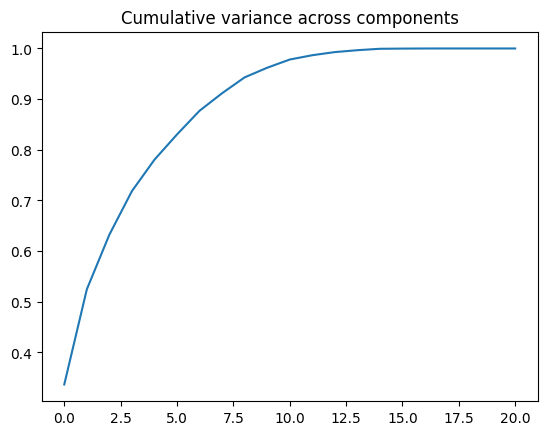

In [ ]:
plt.plot(cumulative_variance)
plt.title('Cumulative variance across components')

Text(0.5, 1.0, 'Eigenvalues')

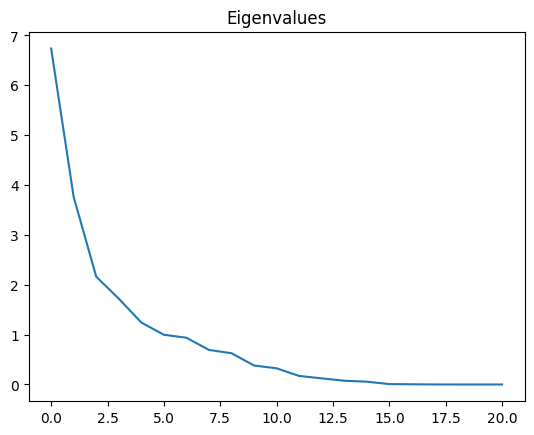

In [ ]:
plt.plot(pca.explained_variance_)
plt.title('Eigenvalues')

In [ ]:
agg_data

,Genotype (F>M),Genotype (FxM),Driver,UAS,Sex,Run number,Monitor number,Channel,Triage for sleep(Last day of activity < 5),Sleep/Day (min),...,Average bout length/L,Average bout length/D,Total activity/L,Total activity/D,Activity/waking min/L,Activity/waking min /D,Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase
0,London>alrm,London>alrmF,alrm,London,F,M96,50,17,0,1042.00,...,43.763158,417.333333,522.25,299.00,0.509885,0.367322,0.375000,0.229259,23.0,9.0
1,London>alrm,London>alrmF,alrm,London,F,M96,50,18,0,744.25,...,19.226415,24.437500,679.00,549.25,0.572875,0.577398,-0.152887,0.115305,22.5,11.0
2,London>alrm,London>alrmF,alrm,London,F,M96,50,20,0,957.00,...,33.238095,143.294118,589.00,306.00,0.539872,0.368231,0.121118,0.092778,22.5,11.0
3,London>alrm,London>alrmF,alrm,London,F,M96,50,21,0,1030.75,...,28.620690,189.692308,366.75,263.75,0.357805,0.320279,0.018836,0.060599,22.0,11.0
4,London>alrm,London>alrmF,alrm,London,F,M96,50,22,0,855.25,...,19.867470,49.000000,481.50,597.50,0.468499,0.598098,0.094266,0.040316,22.0,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,7,0,1083.75,...,9.310559,355.750000,393.25,11.50,0.369162,0.015786,0.250000,0.059462,21.0,10.0
1336,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,8,0,1081.75,...,15.756098,25.210526,263.25,518.75,0.275510,0.616642,-0.175197,0.212707,19.5,10.0
1337,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,9,0,1097.75,...,15.218487,57.400000,330.25,407.50,0.334515,0.513063,0.027311,-0.069477,23.0,10.0
1338,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,11,0,777.00,...,8.718182,35.229508,411.75,190.25,0.343054,0.210745,-0.123177,0.142292,21.5,9.0


In [ ]:
(agg_data['Triage for sleep(Last day of activity <   5)'] != 0).sum()

0

In [ ]:
filtered_cols = [col for col in agg_data.columns if not any(phrase in col for phrase in ['/L', '/D'])]
filtered_cols

['Genotype (F>M)',
 'Genotype (FxM)',
 'Driver',
 'UAS',
 'Sex',
 'Run number',
 'Monitor number',
 'Channel',
 'Triage for sleep(Last day of activity <   5)',
 'Activity/waking min',
 'Latency (min)',
 'Morning Anticipation',
 'Evening Anticipation',
 'Morning Anticipation phase',
 'Evening Anticipation phase']

In [ ]:
agg_data_subset = agg_data[filtered_cols]
agg_data_subset

,Genotype (F>M),Genotype (FxM),Driver,UAS,Sex,Run number,Monitor number,Channel,Triage for sleep(Last day of activity < 5),Activity/waking min,Latency (min),Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase
0,London>alrm,London>alrmF,alrm,London,F,M96,50,17,0,2.063442,72.00,0.375000,0.229259,23.0,9.0
1,London>alrm,London>alrmF,alrm,London,F,M96,50,18,0,1.765361,53.75,-0.152887,0.115305,22.5,11.0
2,London>alrm,London>alrmF,alrm,London,F,M96,50,20,0,1.853002,85.50,0.121118,0.092778,22.5,11.0
3,London>alrm,London>alrmF,alrm,London,F,M96,50,21,0,1.540623,71.00,0.018836,0.060599,22.0,11.0
4,London>alrm,London>alrmF,alrm,London,F,M96,50,22,0,1.845233,32.50,0.094266,0.040316,22.0,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,7,0,1.136140,6.50,0.250000,0.059462,21.0,10.0
1336,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,8,0,2.182833,12.25,-0.175197,0.212707,19.5,10.0
1337,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,9,0,2.155588,8.50,0.027311,-0.069477,23.0,10.0
1338,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,11,0,0.907994,28.50,-0.123177,0.142292,21.5,9.0


In [ ]:
agg_data_subset.iloc[:, 8:]

,Triage for sleep(Last day of activity < 5),Activity/waking min,Latency (min),Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase
0,0,2.063442,72.00,0.375000,0.229259,23.0,9.0
1,0,1.765361,53.75,-0.152887,0.115305,22.5,11.0
2,0,1.853002,85.50,0.121118,0.092778,22.5,11.0
3,0,1.540623,71.00,0.018836,0.060599,22.0,11.0
4,0,1.845233,32.50,0.094266,0.040316,22.0,8.5
...,...,...,...,...,...,...,...
1335,0,1.136140,6.50,0.250000,0.059462,21.0,10.0
1336,0,2.182833,12.25,-0.175197,0.212707,19.5,10.0
1337,0,2.155588,8.50,0.027311,-0.069477,23.0,10.0
1338,0,0.907994,28.50,-0.123177,0.142292,21.5,9.0


In [ ]:
agg_data_subset.to_csv('/home/rachel/Desktop/mm-vae_ext2/data/agg_data_subset.csv', index=False)

In [ ]:
scaler = StandardScaler()
X_agg_subset_scaled = scaler.fit_transform(agg_data_subset.iloc[:, 8:])
pca = PCA()
pca.fit(X_agg_subset_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

Text(0.5, 1.0, 'Cumulative variance across components')

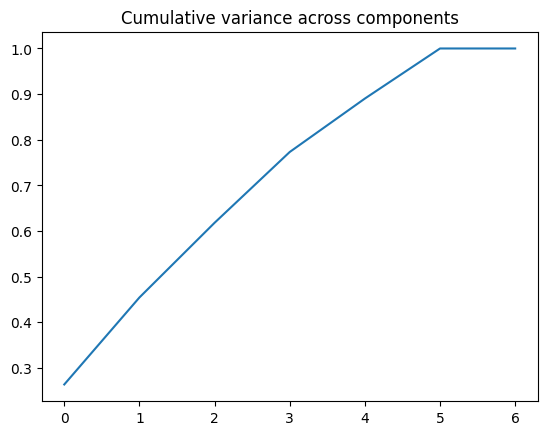

In [ ]:
plt.plot(cumulative_variance)
plt.title('Cumulative variance across components')

Text(0.5, 1.0, 'Eigenvalues')

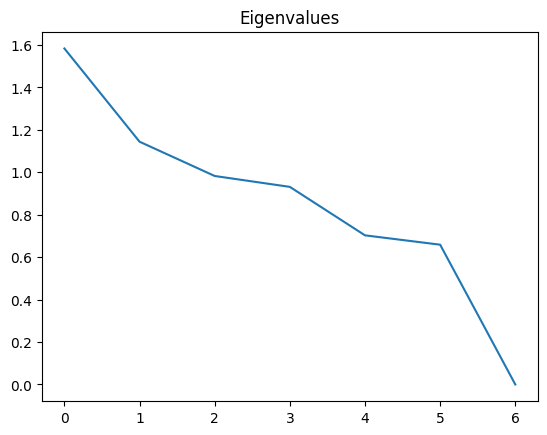

In [ ]:
plt.plot(pca.explained_variance_)
plt.title('Eigenvalues')

In [ ]:
master_binary = pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/master_binary_summary_sheet.csv')
master_binary

,Genotype (F>M),Genotype (FxM),Driver,UAS,Sex,Run number,Monitor number,Channel,Triage for sleep(Last day of activity < 5),Sleep/Day (min),...,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase,P,S,P-S,Period for P-S>0,Period for P-S>=10,Period for P-S>=30,Age
0,London>alrm,London>alrmF,alrm,London,F,M96,50,17,0,1042.00,...,0.229259,23.0,9.0,202.165438,72.443307,129.722130,23.5,23.5,23.5,NaN
1,London>alrm,London>alrmF,alrm,London,F,M96,50,18,0,744.25,...,0.115305,22.5,11.0,164.620655,73.682639,90.938017,24.0,24.0,24.0,NaN
2,London>alrm,London>alrmF,alrm,London,F,M96,50,19,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,London>alrm,London>alrmF,alrm,London,F,M96,50,20,0,957.00,...,0.092778,22.5,11.0,150.504968,73.682639,76.822329,24.0,24.0,24.0,NaN
4,London>alrm,London>alrmF,alrm,London,F,M96,50,21,0,1030.75,...,0.060599,22.0,11.0,170.013877,73.682639,96.331239,24.0,24.0,24.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1702,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,8,0,1081.75,...,0.212707,19.5,10.0,55.081976,50.892181,4.189794,15.0,NaN,NaN,NaN
1703,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,9,0,1097.75,...,-0.069477,23.0,10.0,87.324506,79.843338,7.481168,26.5,NaN,NaN,NaN
1704,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,10,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1705,nsyb>60104,nsybx60104_F,nsyb,60104,F,M153,34,11,0,777.00,...,0.142292,21.5,9.0,87.087492,77.385962,9.701530,25.5,NaN,NaN,NaN


In [ ]:
(master_binary['Triage for sleep(Last day of activity <   5)'] != 0).sum()

367

In [51]:
len(agg_data.columns)

29

In [52]:
len(filtered_cols_overlap)

24

In [47]:
filtered_cols_overlap = [col for col in agg_data.columns if not any(phrase in col for phrase in ['/Day', 'Triage'])]
agg_data[filtered_cols_overlap].iloc[:, 8:]

,Activity/waking min,Latency (min),Sleep/L (min),Sleep/D (min),Bout number/L,Bout number/D,Average bout length/L,Average bout length/D,Total activity/L,Total activity/D,Activity/waking min/L,Activity/waking min /D,Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase
0,2.063442,72.00,415.75,626.00,9.50,1.50,43.763158,417.333333,522.25,299.00,0.509885,0.367322,0.375000,0.229259,23.0,9.0
1,1.765361,53.75,254.75,488.75,13.25,20.00,19.226415,24.437500,679.00,549.25,0.572875,0.577398,-0.152887,0.115305,22.5,11.0
2,1.853002,85.50,349.00,609.00,10.50,4.25,33.238095,143.294118,589.00,306.00,0.539872,0.368231,0.121118,0.092778,22.5,11.0
3,1.540623,71.00,415.00,616.50,14.50,3.25,28.620690,189.692308,366.75,263.75,0.357805,0.320279,0.018836,0.060599,22.0,11.0
4,1.845233,32.50,412.25,441.00,20.75,9.00,19.867470,49.000000,481.50,597.50,0.468499,0.598098,0.094266,0.040316,22.0,8.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1.136140,6.50,374.75,711.50,40.25,2.00,9.310559,355.750000,393.25,11.50,0.369162,0.015786,0.250000,0.059462,21.0,10.0
1336,2.182833,12.25,484.50,598.75,30.75,23.75,15.756098,25.210526,263.25,518.75,0.275510,0.616642,-0.175197,0.212707,19.5,10.0
1337,2.155588,8.50,452.75,645.75,29.75,11.25,15.218487,57.400000,330.25,407.50,0.334515,0.513063,0.027311,-0.069477,23.0,10.0
1338,0.907994,28.50,239.75,537.25,27.50,15.25,8.718182,35.229508,411.75,190.25,0.343054,0.210745,-0.123177,0.142292,21.5,9.0


In [ ]:
agg_data[filtered_cols_overlap].to_csv('/home/rachel/Desktop/mm-vae_ext2/data/agg_data_subset2.csv', index=False)

In [ ]:
scaler = StandardScaler()
X_agg_subset2_scaled = scaler.fit_transform(agg_data[filtered_cols_overlap].iloc[:, 8:])
pca = PCA()
pca.fit(X_agg_subset2_scaled)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

Text(0.5, 1.0, 'Cumulative variance across components')

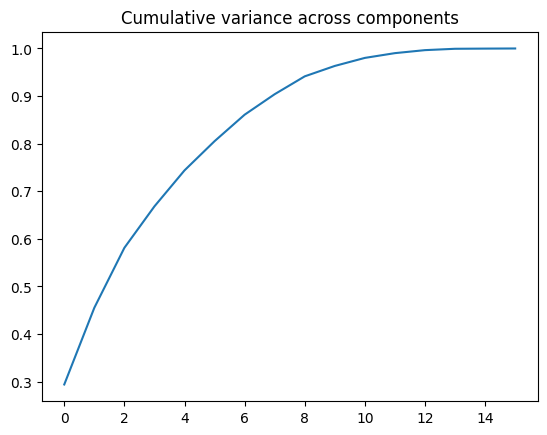

In [ ]:
plt.plot(cumulative_variance)
plt.title('Cumulative variance across components')

Text(0.5, 1.0, 'Eigenvalues')

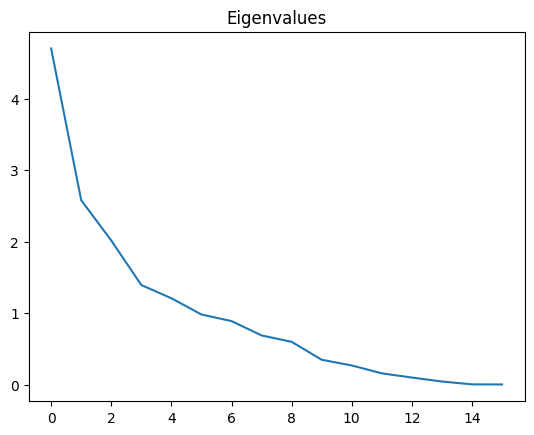

In [ ]:
plt.plot(pca.explained_variance_)
plt.title('Eigenvalues')

In [ ]:
agg_data['Run number'].unique()

array(['M96', 'M106', 'M119', 'M153'], dtype=object)

In [ ]:
run153 = pd.read_excel('/home/rachel/Downloads/M153_forR.xlsx')
run153

,Genotype (FxM)_specsheet,Genotype (F>M),Driver,UAS,Sex,Age,Run number,Monitor number,Channel,Triage for sleep(Last day of activity < 5),...,Morning Anticipation,Evening Anticipation,Morning Anticipation phase,Evening Anticipation phase,P,S,P-S,Period for P-S>0,Period for P-S>=10,Period for P-S>=30
0,attp2xAb42_Arc_F_2,attp2>Ab42-Arc,attp2,Ab42-Arc,F,2.0,M153,30,1,0,...,-0.016603,0.154025,22.5,8.5,97.192903,73.682639,23.510264,24.0,24.0,NaN
1,attp2xAb42_Arc_F_2,attp2>Ab42-Arc,attp2,Ab42-Arc,F,2.0,M153,30,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,attp2xAb42_Arc_F_2,attp2>Ab42-Arc,attp2,Ab42-Arc,F,2.0,M153,30,3,0,...,-0.045886,0.056877,23.0,11.0,102.834852,73.682639,29.152213,24.0,24.0,NaN
3,attp2xAb42_Arc_F_2,attp2>Ab42-Arc,attp2,Ab42-Arc,F,2.0,M153,30,4,0,...,0.066306,0.288481,22.0,10.0,157.542028,73.682639,83.859390,24.0,24.0,24.0
4,attp2xAb42_Arc_F_2,attp2>Ab42-Arc,attp2,Ab42-Arc,F,2.0,M153,30,5,0,...,0.067809,0.108323,19.5,9.5,138.548607,73.682639,64.865969,24.0,24.0,24.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
462,nsybx60104_F,nsyb>60104,nsyb,60104,F,NaN,M153,34,8,0,...,-0.175197,0.212707,19.5,10.0,55.081976,50.892181,4.189794,15.0,NaN,NaN
463,nsybx60104_F,nsyb>60104,nsyb,60104,F,NaN,M153,34,9,0,...,0.027311,-0.069477,23.0,10.0,87.324506,79.843338,7.481168,26.5,NaN,NaN
464,nsybx60104_F,nsyb>60104,nsyb,60104,F,NaN,M153,34,10,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
465,nsybx60104_F,nsyb>60104,nsyb,60104,F,NaN,M153,34,11,0,...,-0.123177,0.142292,21.5,9.0,87.087492,77.385962,9.701530,25.5,NaN,NaN


In [ ]:
pd.read_csv('/home/rachel/Desktop/mm-vae_ext2/data/Monitor8.txt', sep=r'\s+')

,161387,21,Nov,24,12:07:00,51,0,8,0.1,Ct,...,0.26,0.27,0.28,0.29,0.30,0.31,0.32,0.33,0.34,0.35
0,161388,21,Nov,24,12:08:00,51,0,8,0,Ct,...,0,0,0,0,0,0,0,0,0,0
1,161389,21,Nov,24,12:09:00,51,0,8,0,Ct,...,0,0,0,0,0,0,0,0,0,0
2,161390,21,Nov,24,12:10:00,51,0,8,0,Ct,...,0,0,0,0,0,0,0,0,0,0
3,161391,21,Nov,24,12:11:00,51,0,8,0,Ct,...,0,0,0,0,0,0,0,0,0,0
4,161392,21,Nov,24,12:12:00,51,0,8,0,Ct,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20138,181526,5,Dec,24,11:46:00,51,0,8,0,Ct,...,0,0,0,0,0,0,0,0,0,0
20139,181527,5,Dec,24,11:47:00,51,0,8,0,Ct,...,0,0,0,0,0,0,0,0,0,0
20140,181528,5,Dec,24,11:48:00,51,0,8,0,Ct,...,0,0,0,0,0,0,0,0,0,0
20141,181529,5,Dec,24,11:49:00,51,0,8,0,Ct,...,0,0,0,0,0,0,0,0,0,0
